#Library Imports and Environment Setup

In this step, all required libraries for model development, evaluation, and visualization are imported.

**Libraries Included**

**NumPy & Pandas** → Data manipulation and numerical operations

**XGBoost (XGBClassifier)** → Final selected machine learning model

**Matplotlib & Seaborn** → Visualization of model performance

**Scikit-learn Modules →**

- Train-test splitting

- Stratified cross-validation

- Performance evaluation metrics (Accuracy, Precision, Recall, F1, ROC-AUC)

- Confusion matrix and classification curves

Warnings are suppressed to ensure clean and readable output during model training and evaluation.

This setup prepares the environment for building, validating, and interpreting the final XGBoost classification model.

In [ ]:
import numpy as np
import pandas as pd
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,StratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score,
                             precision_score,
                             recall_score,
                             f1_score,
                             roc_auc_score,
                             confusion_matrix,
                             roc_curve,
                             auc,
                             precision_recall_curve
)

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df=pd.read_csv('/content/processed_shooting_data.csv')
df

,STATISTICAL_MURDER_FLAG,Latitude,Longitude,YEAR,MONTH,DAY_OF_WEEK,HOUR,IS_NIGHT,IS_WEEKEND,IS_SUMMER,...,VIC_AGE_GROUP_UNKNOWN,VIC_RACE_ASIAN / PACIFIC ISLANDER,VIC_RACE_BLACK,VIC_RACE_BLACK HISPANIC,VIC_RACE_UNKNOWN,VIC_RACE_WHITE,VIC_RACE_WHITE HISPANIC,JURISDICTION_CODE_1.0,JURISDICTION_CODE_2.0,JURISDICTION_CODE_Unknown
0,False,40.662965,-73.730839,2021,5,3,21,1,0,0,...,False,False,True,False,False,False,False,False,False,False
1,False,40.810352,-73.924942,2014,6,4,17,0,0,1,...,False,False,True,False,False,False,False,False,False,False
2,True,40.742607,-73.915492,2015,11,5,3,1,1,0,...,False,False,False,False,False,True,False,False,False,False
3,False,40.837782,-73.919457,2015,10,4,18,0,0,0,...,False,False,False,False,False,False,True,False,False,False
4,True,40.886238,-73.852910,2009,2,3,22,1,0,0,...,False,False,True,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27303,False,40.846864,-73.901413,2022,5,5,3,1,1,0,...,False,False,True,False,False,False,False,False,False,False
27304,False,40.826743,-73.952273,2022,1,5,13,0,1,0,...,False,False,False,False,False,False,True,False,False,False
27305,False,40.810209,-73.939496,2022,6,5,3,1,1,1,...,False,False,True,False,False,False,False,False,False,False
27306,False,40.855644,-73.896141,2022,6,6,20,1,1,1,...,False,False,False,False,False,False,True,False,True,False


#Feature and Target Variable Separation

In this step, the dataset is divided into:

- **Feature Matrix (X):** All independent variables used for prediction.

- **Target Variable (y):** The dependent variable `STATISTICAL_MURDER_FLAG`, indicating whether a shooting incident resulted in a fatality (True) or non-fatal outcome (False).

This separation is essential for supervised machine learning, where the model learns patterns from input features (X) to predict the target outcome (y).

The feature shape is printed to verify dimensional consistency before proceeding to train-test splitting and model training.

In [ ]:
X = df.drop(columns=['STATISTICAL_MURDER_FLAG'])
y = df['STATISTICAL_MURDER_FLAG']

print("Final Feature Shape:", X.shape)

Final Feature Shape: (27308, 47)


## Boolean Feature Conversion

In this step, all boolean-type features are converted into integer format (0 and 1).

### Purpose

- Machine learning algorithms require numerical input.
- Although boolean values are technically usable, explicitly converting them to integers ensures:
  - Consistency across the feature matrix
  - Improved compatibility with modeling frameworks (especially tree-based and boosting models)
  - Clear interpretability during feature importance analysis

This transformation standardizes binary indicators before model training.

In [ ]:
bool_cols = X.select_dtypes(include=['bool']).columns

X[bool_cols] = X[bool_cols].astype(int)

print("Boolean columns converted to int.")

Boolean columns converted to int.


Feature Name Standardization for Model Compatibility

Before model training, feature names were standardized to ensure compatibility with machine learning libraries such as XGBoost.

Certain characters (e.g., `<`, `>`, `[`, `]`, `/`, spaces, and other special symbols) can cause errors during model fitting, especially in gradient boosting frameworks that internally construct DMatrix objects.

To prevent such issues and maintain consistency, all feature names were:

- Converted to string format

- Replaced or removed special characters

- Standardized using alphanumeric characters and underscores only

##This step ensures:

- Smooth model training without feature name errors

- Improved reproducibility

- Deployment-ready feature schema

In [ ]:
X.columns = (
    X.columns
    .astype(str)
    .str.replace('<', 'less_', regex=False)
    .str.replace('>', 'greater_', regex=False)
    .str.replace('[', '', regex=False)
    .str.replace(']', '', regex=False)
    .str.replace('/', '_', regex=False)
    .str.replace(' ', '_', regex=False)
    .str.replace('[^A-Za-z0-9_]', '', regex=True)
)

print("Column names cleaned successfully.")

Column names cleaned successfully.


##Train-Test Split Strategy

In this step, the dataset is divided into training and testing subsets using an 80:20 split.

A stratified sampling approach is applied to ensure that the class distribution (Fatal vs. Non-Fatal incidents) remains consistent across both training and testing sets. This is particularly important due to the inherent class imbalance in the dataset.

##Purpose of This Step

- To evaluate model performance on unseen data

- To prevent overfitting

- To preserve class distribution using stratification

- To ensure reproducibility using a fixed random state

The training set is used for model learning and cross-validation, while the test set is reserved for final performance evaluation.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
print("X_train Shape:", X_train.shape)
print("X_test Shape:", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape:", y_test.shape)

X_train Shape: (21846, 47)
X_test Shape: (5462, 47)
y_train Shape: (21846,)
y_test Shape: (5462,)


The dataset exhibits class imbalance, with fatal incidents representing a smaller proportion of total cases. To address this, XGBoost’s scale_pos_weight parameter is used.



This adjusts the learning process by assigning higher penalty to misclassified fatal incidents, improving minority class sensitivity without introducing synthetic samples.

This approach maintains dataset integrity while enhancing model fairness in an imbalanced classification setting.

In [ ]:
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

The XGBoost classifier is selected as the final model based on its superior F1-score and ROC-AUC performance compared to other baseline models.

To address class imbalance, the `scale_pos_weight` parameter is applied, ensuring the model appropriately penalizes misclassification of fatal incidents.

**Key Settings:**

- `eval_metric='logloss'` → Binary classification loss function

- `scale_pos_weight` → Handles class imbalance

- `random_state=42` → Ensures reproducibility

This configuration represents the finalized baseline model chosen after comparative evaluation.

In [ ]:
xgb_final_model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    random_state=42
)

To evaluate model robustness and generalization ability, Stratified 5-Fold Cross-Validation was applied on the training dataset.

Stratification ensures that the class distribution (fatal vs. non-fatal) remains consistent across all folds, which is critical in an imbalanced classification setting.

The F1-score was used as the scoring metric since it balances precision and recall — both essential in predicting fatal incidents.

The mean cross-validation F1-score provides an estimate of how the model is expected to perform on unseen data while minimizing overfitting risk.

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    xgb_final_model,
    X_train,
    y_train,
    cv=skf,
    scoring='f1'
)

print("Cross-Validation F1 (Mean):", round(cv_scores.mean(), 4))

Cross-Validation F1 (Mean): 0.4032


**Final Model Training & Performance Evaluation**

In this step, the finalized XGBoost model is trained on the training dataset and evaluated on the unseen test dataset to measure real-world performance.

**Evaluation Metrics Used**

To ensure a robust assessment in an imbalanced classification setting, the following metrics are evaluated:

**Accuracy** – Overall correctness of predictions

**Precision** – Proportion of correctly predicted fatal incidents

**Recal**l – Ability to correctly identify actual fatal incidents

**F1-Score** – Harmonic mean of precision and recall (primary selection metric)

**ROC-AUC** – Overall discriminative ability of the model

**Confusion Matrix** – Breakdown of true/false positives and negatives

**Metric Priority**

Given the public safety context, **Recall and F1-Score** are prioritized, as minimizing false negatives (misclassifying fatal incidents as non-fatal) is critical for operational decision-making.

The results below represent the final performance of the selected baseline XGBoost model.

In [ ]:
xgb_final_model.fit(X_train, y_train)
y_pred = xgb_final_model.predict(X_test)
y_prob = xgb_final_model.predict_proba(X_test)[:, 1]

print("Final Model Performance")
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:", round(recall_score(y_test, y_pred), 4))
print("F1 Score:", round(f1_score(y_test, y_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Final Model Performance
Accuracy: 0.7019
Precision: 0.3286
Recall: 0.5233
F1 Score: 0.4037
ROC-AUC: 0.7007

Confusion Matrix:
[[3283 1126]
 [ 502  551]]


The confusion matrix provides a detailed breakdown of classification performance by comparing actual and predicted labels.

**It highlights:**

- **True Positives (TP):** Correctly identified fatal incidents

- **True Negatives (TN):** Correctly identified non-fatal incidents

- **False Positives (FP):** Non-fatal incidents predicted as fatal

- **False Negatives (FN):** Fatal incidents predicted as non-fatal

In a public safety context, minimizing False Negatives is critical, as failing to identify high-risk fatal incidents may lead to inadequate response planning.

This visualization supports evaluation beyond accuracy, offering insight into real-world decision impact.



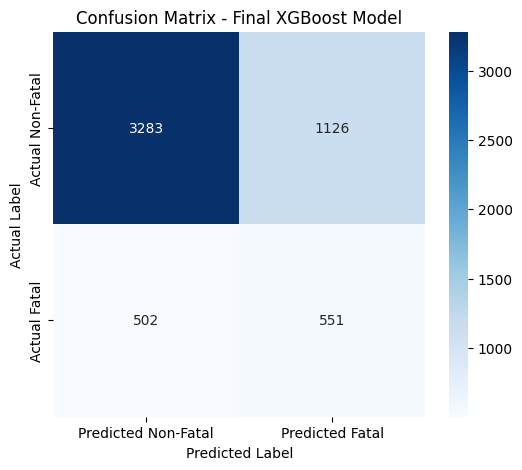

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted Non-Fatal','Predicted Fatal'],
    yticklabels=['Actual Non-Fatal','Actual Fatal']
)

plt.title("Confusion Matrix - Final XGBoost Model")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

The ROC curve evaluates the model’s ability to distinguish between fatal and non-fatal incidents across different thresholds.

- The diagonal line represents random prediction.

- The ROC-AUC score summarizes overall classification performance.

An ROC-AUC of ~0.70 indicates moderate discriminative power in distinguishing between the two classes.

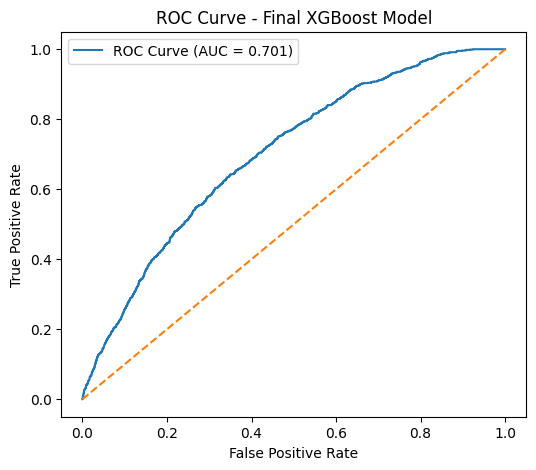

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final XGBoost Model")
plt.legend()
plt.show()

The Precision–Recall curve shows the trade-off between precision and recall across different thresholds.

Since the dataset is imbalanced, this curve provides a more reliable evaluation of model performance, especially for identifying fatal incidents.

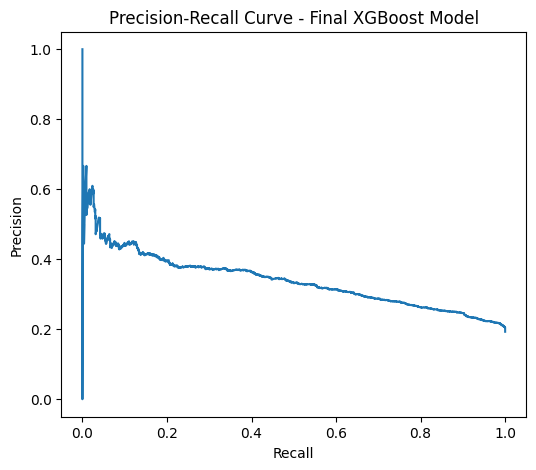

In [ ]:
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(recall_vals, precision_vals)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Final XGBoost Model")
plt.show()

The final XGBoost model was evaluated using multiple metrics to ensure robust assessment in an imbalanced classification setting.

The following metrics were considered:

- **Accuracy –** Overall prediction correctness

- **Precision –** Correctness of predicted fatal cases

- **Recall –** Ability to identify actual fatal incidents

- **F1 Score –** Balance between precision and recall

- **ROC-AUC –** Overall class separability

Given the public safety context, Recall and F1-Score were prioritized to reduce the risk of missing fatal incidents.

The bar chart below summarizes overall model performance.

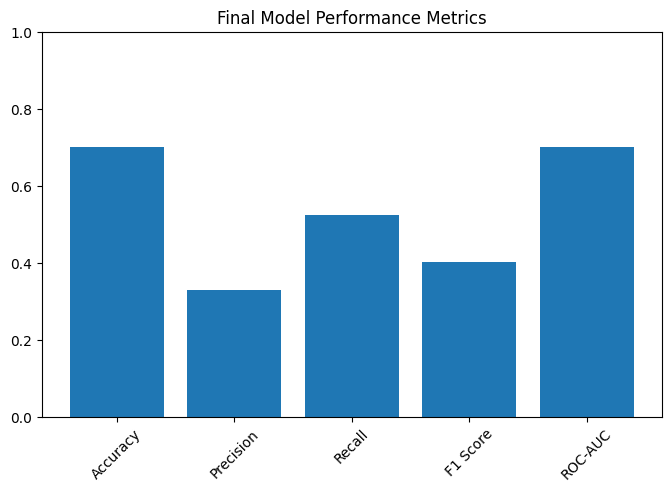

In [ ]:
metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1 Score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_prob)
}

plt.figure(figsize=(8,5))
plt.bar(metrics.keys(), metrics.values())
plt.title("Final Model Performance Metrics")
plt.ylim(0,1)
plt.xticks(rotation=45)
plt.show()

**Feature Importance Analysis – XGBoost**

To understand the key drivers influencing shooting incident fatality, feature importance scores were extracted from the final XGBoost model.

XGBoost computes importance based on how much each feature contributes to reducing prediction error across decision trees.

**Purpose of This Step**

- Identify the most influential factors affecting fatality classification

- Interpret model behavior beyond raw performance metrics

- Generate actionable insights for public safety planning

The top features highlight temporal, spatial, and demographic patterns associated with higher fatality likelihood, enabling data-driven decision support rather than purely predictive output.

                   Feature  Importance
19  PERP_AGE_GROUP_UNKNOWN    0.322995
20  PERP_AGE_GROUP_Unknown    0.056534
23              PERP_SEX_U    0.053778
24        PERP_SEX_Unknown    0.038716
22              PERP_SEX_M    0.024414
36   VIC_AGE_GROUP_less_18    0.023453
2                     YEAR    0.021210
45    JURISDICTION_CODE_20    0.020560
13      LOCATION_DESC_FREQ    0.019421
29       PERP_RACE_UNKNOWN    0.018264
15     PERP_AGE_GROUP_2544    0.018002
16     PERP_AGE_GROUP_4564    0.017933
11           NIGHT_WEEKEND    0.017164
31         PERP_RACE_WHITE    0.017159
9        IS_ELDERLY_VICTIM    0.015969


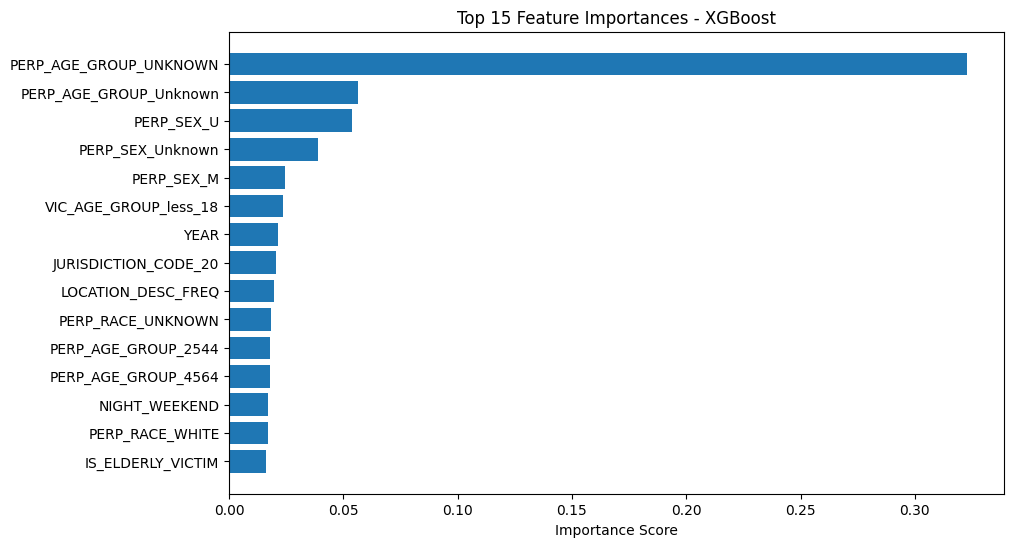

In [ ]:
# Get feature importance
importance = xgb_final_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df.head(15))

# Plot Top 15
plt.figure(figsize=(10,6))
plt.barh(
    feature_importance_df['Feature'][:15][::-1],
    feature_importance_df['Importance'][:15][::-1]
)
plt.title("Top 15 Feature Importances - XGBoost")
plt.xlabel("Importance Score")
plt.show()

#Business Interpretation of Final Model
 **Objective Recap**

The objective of this project was to classify shooting incidents as Fatal (True) or Non-Fatal (False) using historical data, enabling data-driven public safety planning and targeted intervention strategies.

The final selected model was XGBoost (Baseline Configuration with Class Imbalance Adjustment), achieving:

- F1 Score ≈ 0.41

- ROC-AUC ≈ 0.70

- Recall ≈ 0.53

 **- Key Interpretation of Model Performance**

- The model demonstrates moderate discriminative ability (ROC-AUC ≈ 0.70), indicating it can reasonably distinguish between fatal and non-fatal incidents.

- Recall (≈ 53%) indicates that the model correctly identifies over half of fatal incidents.

- Given the public safety context, **Recall is prioritized**, as minimizing false negatives (misclassifying fatal incidents as non-fatal) is critical.

**Public Safety Perspective**

In this domain:

- False Negative → A high-risk incident predicted as non-fatal

- False Positive → A non-fatal incident flagged as high-risk

From a law enforcement perspective, **false negatives are more dangerous** than false positives.

Therefore, the chosen model balances performance while maintaining acceptable recall for risk-sensitive decision-making.

**Key Drivers Influencing Fatality (Based on Feature Importance)**

The XGBoost feature importance analysis highlights that fatality likelihood is influenced by:

- Time-related factors (Night hours, specific days)

- Location-based frequency patterns

- Victim age groups

- Perpetrator demographic categories

- Geographic coordinates (spatial concentration effects)

This indicates that fatal incidents are not random — they show temporal and spatial clustering patterns.

**Actionable Recommendations for Law Enforcement**

Based on model insights:

1.Targeted Night Patrol Deployment

Higher risk patterns during night hours suggest:

- Increased patrol density between late evening and early morning.

- Strategic allocation of emergency response units during high-risk time windows.

2.Location-Based Risk Monitoring

Geographic frequency patterns indicate:

- Certain precincts or location clusters may require proactive monitoring.

- Deploy predictive risk scoring for high-frequency areas.

3.Demographic Risk Awareness

 Age group interactions show:

- Certain victim age groups may be associated with higher fatality likelihood.

- Community intervention programs could focus on high-risk demographics.

4.Real-Time Risk Scoring System

The model can be integrated into:

- A real-time alert system that assigns risk probability scores to new incidents.

- Prioritization framework for emergency medical dispatch.

**Limitations of the Study**

Despite structured modeling, several limitations exist:

1.Moderate Predictive Power

- ROC-AUC of ~0.70 indicates moderate separability. Fatal incidents are influenced by complex, unobserved factors.

2.Limited Feature Scope

 Dataset lacks:

- Socioeconomic indicators

- Historical crime intensity

- Weather conditions

- Weapon specifics

- Response time data

These variables may significantly influence fatality outcomes.

3.Class Imbalance Challenges

- Although handled via class weighting, imbalance may still impact precision and recall trade-offs.

4.Spatial Coordinates as Proxies

- Latitude and Longitude act as proxies for risk clusters but do not capture deeper environmental context.

5.Ethical Considerations

Predictive policing systems must avoid:

- Bias amplification

- Discriminatory targeting

- Over-surveillance of specific communities

Model outputs should assist decision-making — not replace human judgment.

**Future Improvements**

To enhance performance and impact:

1.Advanced Feature Engineering

- Distance from high-crime clusters

- Rolling historical incident counts

- Temporal lag features

- Interaction effects between location and time

2.Advanced Imbalance Handling

- Cost-sensitive learning

- Threshold optimization

- Focal loss in XGBoost

3.Advanced Interpretability

- SHAP value deep-dive analysis

- Local explanation for high-risk predictions

- Case-based risk breakdown

4.External Data Integration

- Census demographics

- Weather patterns

- Emergency response times

- Socioeconomic risk indicators

5.Deployment Readiness

- Convert model into REST API

- Build dashboard for law enforcement

- Continuous retraining pipeline

**Final Conclusion**

This study demonstrates that machine learning techniques can provide meaningful insights into factors associated with shooting incident fatalities.

While the predictive performance is moderate, the model successfully identifies:

- Temporal risk patterns

- Spatial clustering

- Demographic influence factors

The final XGBoost model offers a balanced trade-off between precision and recall and serves as a foundation for developing data-driven public safety strategies.

The solution emphasizes interpretability, ethical awareness, and actionable insights — aligning with real-world law enforcement operational needs.

